<a href="https://colab.research.google.com/github/MO7AMEDNABIL/News-Category-Classification-/blob/main/News_Category_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train= pd.read_csv("/content/train.csv")
df_test= pd.read_csv("/content/test.csv")

In [3]:
df_train.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [5]:
df_train.describe()

,Class Index
count,120000.000000
mean,2.500000
std,1.118039
min,1.000000
25%,1.750000
50%,2.500000
75%,3.250000
max,4.000000


In [6]:
df_train.isnull().sum()

,0
Class Index,0
Title,0
Description,0


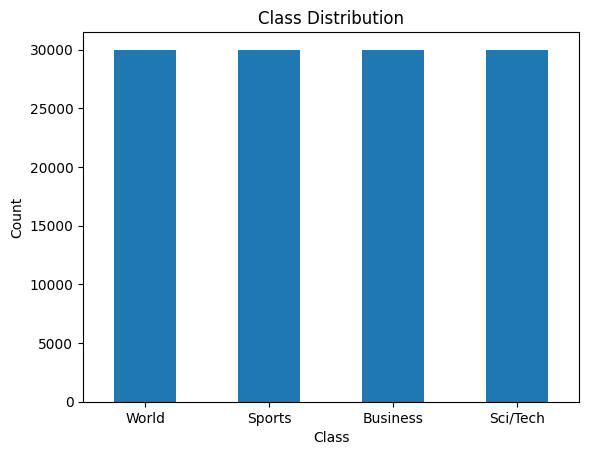

In [7]:
counts = df_train["Class Index"].value_counts().sort_index()

class_names = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

counts.index = counts.index.map(class_names)

counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

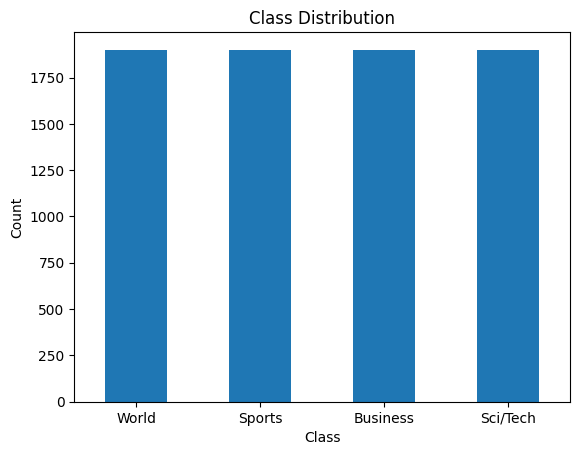

In [8]:
counts = df_test["Class Index"].value_counts().sort_index()

class_names = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

counts.index = counts.index.map(class_names)

counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [9]:
df_train["text"] = df_train["Title"] + " [SEP] " + df_train["Description"]
df_test["text"] = df_test["Title"] + " [SEP] " + df_test["Description"]

In [10]:
df_train.head()

,Class Index,Title,Description,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


In [11]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.4 MB/s eta 0:00:00


In [12]:
import re
import contractions

def clean_reviews_text(text):

    text = contractions.fix(text)

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#(\w+)', r'\1', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^\w\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_train['text'] = df_train['text'].apply(clean_reviews_text)
df_train['text'].head()

,text
0,wall st bears claw back into the black reuters...
1,carlyle looks toward commercial aerospace reut...
2,oil and economy cloud stocks outlook reuters s...
3,iraq halts oil exports from main southern pipe...
4,oil prices soar to alltime record posing new m...


In [13]:
df_test['text'] = df_test['text'].apply(clean_reviews_text)
df_test['text'].head()

,text
0,fears for t n pension after talks sep unions r...
1,the race is on second private team sets launch...
2,ky company wins grant to study peptides ap sep...
3,prediction unit helps forecast wildfires ap se...
4,calif aims to limit farmrelated smog ap sep ap...


In [14]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download("punkt")
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [15]:
from nltk.corpus import wordnet
from nltk import pos_tag

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

In [16]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

lemmatizer=WordNetLemmatizer()

stop_words = set(stopwords.words("english"))
important_words = {"not", "no", "never", "neither", "nor", "barely", "hardly"}
stop_words = stop_words - important_words

def lemmatize_text(text):
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)

    lemmatized_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]

    filtered_tokens = [
        word for word in lemmatized_tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(filtered_tokens)

df_train['text'] = df_train['text'].apply(lemmatize_text)
df_train['text'].head()

,text
0,wall bear claw back black reuters sep reuters ...
1,carlyle look toward commercial aerospace reute...
2,oil economy cloud stock outlook reuters sep re...
3,iraq halt oil export main southern pipeline re...
4,oil price soar alltime record pose new menace ...


In [17]:
df_test['text'] = df_test['text'].apply(lemmatize_text)
df_test['text'].head()

,text
0,fear pension talk sep union represent worker t...
1,race second private team set launch date human...
2,company win grant study peptide sep company fo...
3,prediction unit help forecast wildfire sep bar...
4,calif aim limit farmrelated smog sep southern ...


In [18]:
x_train = df_train["text"]
y_train = df_train["Class Index"]

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(df_test["text"])

In [20]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(x_train_tfidf, y_train)

LogisticRegression(max_iter=2000)

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(x_train_tfidf, y_train)

RandomForestClassifier()

In [26]:
from sklearn.metrics import classification_report
lr_predictions = lr_model.predict(x_test_tfidf)
print(classification_report(df_test['Class Index'], lr_predictions, target_names=["World", "Sports", "Business", "Sci/Tech"]))

              precision    recall  f1-score   support

       World       0.93      0.90      0.91      1900
      Sports       0.95      0.98      0.97      1900
    Business       0.88      0.88      0.88      1900
    Sci/Tech       0.89      0.90      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



In [27]:
rf_predictions = rf_model.predict(x_test_tfidf)
print(classification_report(df_test['Class Index'], rf_predictions, target_names=["World", "Sports", "Business", "Sci/Tech"]))

              precision    recall  f1-score   support

       World       0.92      0.89      0.90      1900
      Sports       0.93      0.98      0.95      1900
    Business       0.86      0.85      0.86      1900
    Sci/Tech       0.87      0.86      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.89      0.90      0.89      7600
weighted avg       0.89      0.90      0.89      7600



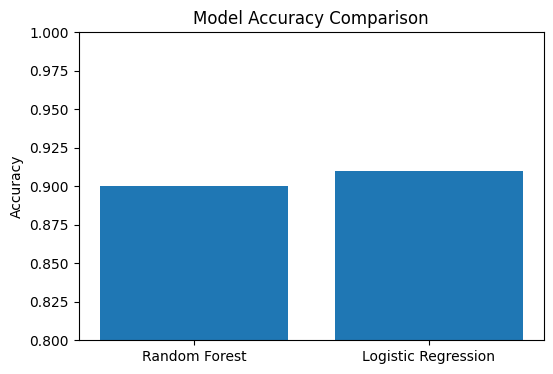

In [40]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'Logistic Regression']
accuracy = [0.90, 0.91]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)

plt.show()

In [32]:
sample_index = 6900 # Or any other index
sample_text = df_test['text'][sample_index]

# transform using SAME vectorizer
sample_tfidf = vectorizer.transform([sample_text])

# prediction for random forest
pred_index = rf_model.predict(sample_tfidf)[0]

# Get the class name using the mapping
predicted_class_name = class_names[pred_index]

print("Original Text:", sample_text)
print("Predicted Class Index:", pred_index)
print("Predicted Class Name:", predicted_class_name)

Original Text: stock midst mixed sign sep stock edge high friday another drop oil price help wall street withstand effect disappointing job creation report
Predicted Class Index: 3
Predicted Class Name: Business


In [42]:
sample_index = 6500
sample_text = df_test['text'][sample_index]


sample_tfidf = vectorizer.transform([sample_text])

# prediction for logistic regression
pred_index = lr_model.predict(sample_tfidf)[0]

predicted_class_name = class_names[pred_index]

print("Original Text:", sample_text)
print("Predicted Class Index:", pred_index)
print("Predicted Class Name:", predicted_class_name)

Original Text: shockwaves sumatra sep indian ocean earthquake december produce shockwave create tsunami across indian ocean tsunami hammer nearby indonesia struck far coast east africa death toll climb continue grow also create social shockwaves
Predicted Class Index: 1
Predicted Class Name: World


In [43]:
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")

['random_forest_model.pkl']